## Imports and Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from collections import Counter

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Imports and NLTK downloads completed.")

[nltk_data] Downloading package stopwords to C:\Users\MIR SHAHADUT
[nltk_data]     HOSSAIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\MIR SHAHADUT
[nltk_data]     HOSSAIN\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\MIR SHAHADUT
[nltk_data]     HOSSAIN\AppData\Roaming\nltk_data...


Imports and NLTK downloads completed.


## Load the Dataset

In [5]:
# Load the CSV file (replace with your actual path)
df = pd.read_csv('aggression_parsed_dataset.csv')

# Basic inspection
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nFirst 5 Rows:\n", df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Prerequisite Test: Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicates. New Shape: {df.shape}")

# Save a copy for reference
df.to_csv('original_dataset_backup.csv', index=False)

Dataset Shape: (115864, 5)

Columns: Index(['index', 'Text', 'ed_label_0', 'ed_label_1', 'oh_label'], dtype='object')

First 5 Rows:
    index                                               Text  ed_label_0  \
0      0  `- This is not ``creative``.  Those are the di...    0.900000   
1      1  `  :: the term ``standard model`` is itself le...    1.000000   
2      2    True or false, the situation as of March 200...    1.000000   
3      3   Next, maybe you could work on being less cond...    0.555556   
4      4               This page will need disambiguation.     1.000000   

   ed_label_1  oh_label  
0    0.100000         0  
1    0.000000         0  
2    0.000000         0  
3    0.444444         0  
4    0.000000         0  

Data Types:
 index           int64
Text           object
ed_label_0    float64
ed_label_1    float64
oh_label        int64
dtype: object

Missing Values:
 index         0
Text          0
ed_label_0    0
ed_label_1    0
oh_label      0
dtype: int64

Number of

## Exploratory Data Analysis (EDA) - Class Distribution


Class Distribution (oh_label):
oh_label
0    87.241939
1    12.758061
Name: proportion, dtype: float64


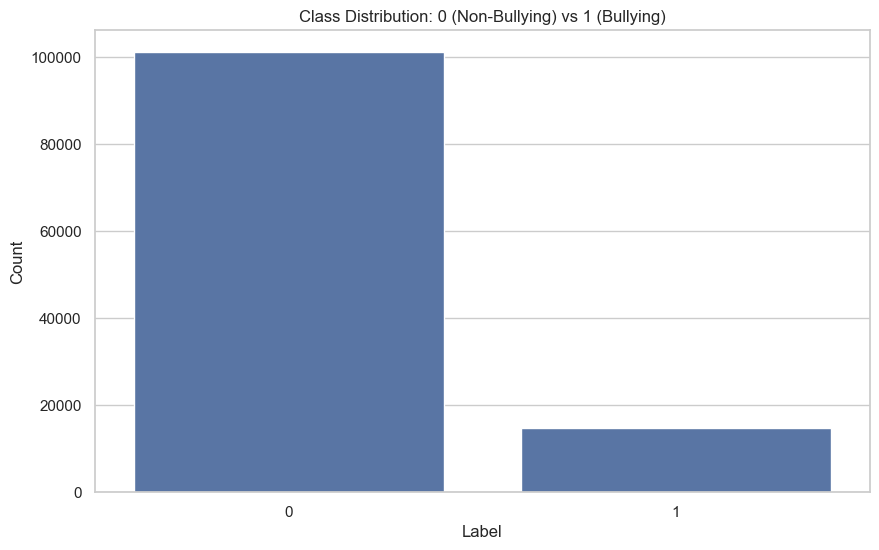

Imbalance Ratio (Non-Bullying to Bullying): 6.84


In [6]:
# Target: 'oh_label' (0: Non-bullying, 1: Bullying)
print("\nClass Distribution (oh_label):")
print(df['oh_label'].value_counts(normalize=True) * 100)

# Visualize class imbalance
sns.countplot(x='oh_label', data=df)
plt.title('Class Distribution: 0 (Non-Bullying) vs 1 (Bullying)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Prerequisite Test: Imbalance Ratio
imbalance_ratio = df['oh_label'].value_counts()[0] / df['oh_label'].value_counts()[1]
print(f"Imbalance Ratio (Non-Bullying to Bullying): {imbalance_ratio:.2f}")

## EDA - Text Length Analysis


Text Length Statistics:
 count    115864.000000
mean        412.405078
std         744.717242
min           5.000000
25%          95.000000
50%         204.000000
75%         434.000000
max       10000.000000
Name: text_length, dtype: float64


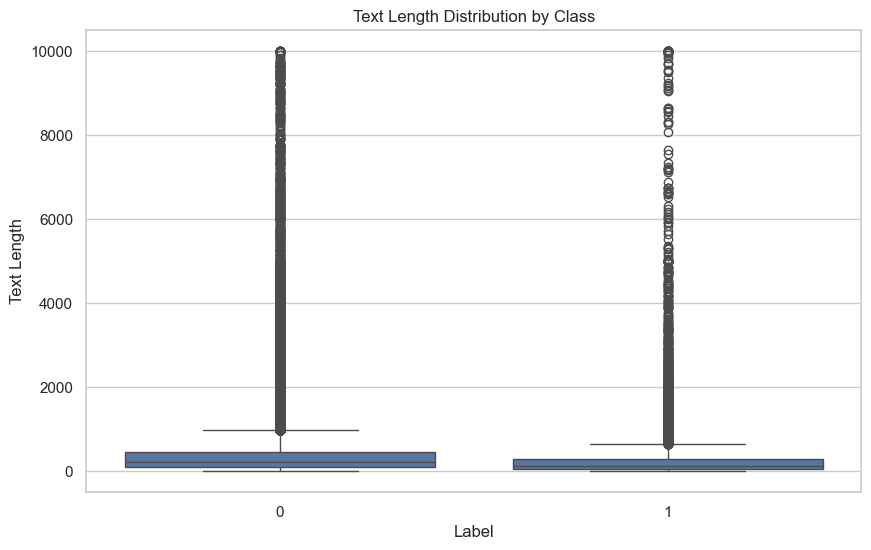

Very Short Texts (<10 chars): 53
Very Long Texts (>2000 chars): 3095


In [7]:
# Add text length column
df['text_length'] = df['Text'].apply(len)

# Statistics
print("\nText Length Statistics:\n", df['text_length'].describe())

# Visualize text lengths by class
sns.boxplot(x='oh_label', y='text_length', data=df)
plt.title('Text Length Distribution by Class')
plt.xlabel('Label')
plt.ylabel('Text Length')
plt.show()

# Prerequisite Test: Check for very short/long texts
short_texts = df[df['text_length'] < 10].shape[0]
long_texts = df[df['text_length'] > 2000].shape[0]
print(f"Very Short Texts (<10 chars): {short_texts}")
print(f"Very Long Texts (>2000 chars): {long_texts}")

## EDA - Word Frequency and N-Grams

In [8]:
# Function to get top n-grams
def get_top_ngrams(corpus, ngram_range=(1,1), n=10):
    vec = TfidfVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

# Top unigrams for each class
non_bullying_text = ' '.join(df[df['oh_label'] == 0]['Text'])
bullying_text = ' '.join(df[df['oh_label'] == 1]['Text'])

print("\nTop 10 Unigrams in Non-Bullying Texts:", get_top_ngrams(non_bullying_text.split()))
print("Top 10 Unigrams in Bullying Texts:", get_top_ngrams(bullying_text.split()))

# Prerequisite Test: Common words overlap
non_bullying_words = set([w[0] for w in get_top_ngrams(non_bullying_text.split(), n=50)])
bullying_words = set([w[0] for w in get_top_ngrams(bullying_text.split(), n=50)])
overlap = non_bullying_words.intersection(bullying_words)
print(f"\nOverlapping Top Words Between Classes: {len(overlap)} words")
print(overlap)


Top 10 Unigrams in Non-Bullying Texts: [('the', np.float64(336675.0346534793)), ('to', np.float64(197169.68329370787)), ('of', np.float64(155922.8833153365)), ('and', np.float64(153623.56233317335)), ('is', np.float64(120509.20850042967)), ('you', np.float64(118066.76269572739)), ('that', np.float64(110000.5751680266)), ('in', np.float64(100556.99133596814)), ('it', np.float64(99580.3488106968)), ('for', np.float64(66133.04013739353))]
Top 10 Unigrams in Bullying Texts: [('you', np.float64(47288.42018274278)), ('the', np.float64(23324.335238914264)), ('to', np.float64(18287.793893950806)), ('and', np.float64(17811.480869406067)), ('is', np.float64(15289.598339996592)), ('fuck', np.float64(13680.11885060208)), ('of', np.float64(13014.06862464289)), ('your', np.float64(10648.972611694611)), ('are', np.float64(9184.888063631528)), ('that', np.float64(9057.379299223749))]

Overlapping Top Words Between Classes: 32 words
{'wikipedia', 'can', 'an', 'my', 'what', 'you', 'all', 'me', 'will', 

## EDA - Word Clouds for Visualization

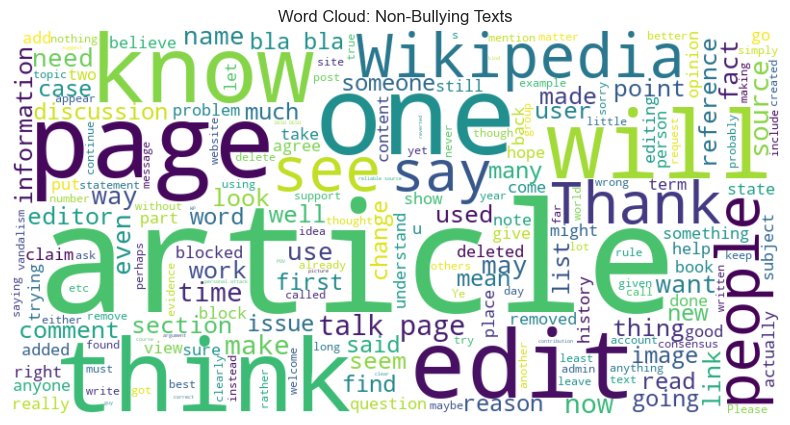

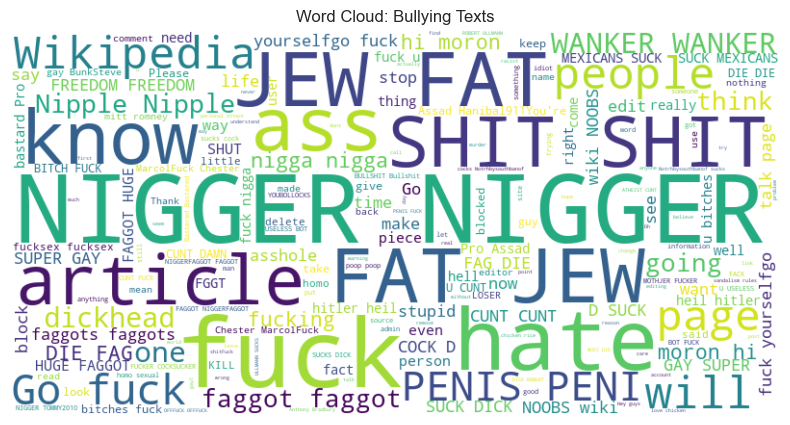

In [9]:
# Word cloud for non-bullying
wordcloud_non = WordCloud(width=800, height=400, background_color='white').generate(non_bullying_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_non, interpolation='bilinear')
plt.title('Word Cloud: Non-Bullying Texts')
plt.axis('off')
plt.show()

# Word cloud for bullying
wordcloud_bully = WordCloud(width=800, height=400, background_color='white').generate(bullying_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_bully, interpolation='bilinear')
plt.title('Word Cloud: Bullying Texts')
plt.axis('off')
plt.show()

## Data Preprocessing - Text Cleaning

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove usernames
    text = re.sub(r'[^a-z\s]', ' ', text)  # Remove special chars
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])  # Lemmatize & remove stopwords
    return text.strip()

# Apply cleaning
df['cleaned_text'] = df['Text'].apply(clean_text)

# Prerequisite Test: Check cleaned text samples
print("\nSample Original vs Cleaned Text:")
for i in range(3):
    print(f"Original: {df['Text'].iloc[i][:100]}...")
    print(f"Cleaned: {df['cleaned_text'].iloc[i][:100]}...\n")

# Update text length after cleaning
df['cleaned_length'] = df['cleaned_text'].apply(len)
print("Cleaned Text Length Statistics:\n", df['cleaned_length'].describe())


Sample Original vs Cleaned Text:
Original: `- This is not ``creative``.  Those are the dictionary definitions of the terms ``insurance`` and ``...
Cleaned: creative dictionary definition term insurance ensurance properly applied destruction understand fine...

Original: `  :: the term ``standard model`` is itself less NPOV than I think we'd prefer...  :: if it's ``new-...
Cleaned: term standard model less npov think prefer new age speak lot old age people speak karl popper pope e...

Original:   True or false, the situation as of March 2002 was such:  A Saudi proposal of Land for Peace AND re...
Cleaned: true false situation march saudi proposal land peace recognition arab country made day proposal made...

Cleaned Text Length Statistics:
 count    115864.000000
mean        249.244908
std         488.723685
min           0.000000
25%          52.000000
50%         118.000000
75%         258.000000
max       10000.000000
Name: cleaned_length, dtype: float64


## Handle Class Imbalance with SMOTE

In [11]:
# Vectorize first for SMOTE (since SMOTE needs numerical features)
temp_vectorizer = TfidfVectorizer(max_features=5000)
X_temp = temp_vectorizer.fit_transform(df['cleaned_text'])
y = df['oh_label']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_temp, y)

# Convert back to DataFrame for consistency
df_resampled = pd.DataFrame({'cleaned_text': temp_vectorizer.inverse_transform(X_resampled), 'oh_label': y_resampled})
df_resampled['cleaned_text'] = df_resampled['cleaned_text'].apply(lambda x: ' '.join(x))

print("\nResampled Class Distribution:")
print(y_resampled.value_counts())

# Prerequisite Test: Verify no data leakage (SMOTE on train later, but for EDA it's fine)


Resampled Class Distribution:
oh_label
0    101082
1    101082
Name: count, dtype: int64


## Feature Extraction with TF-IDF

In [12]:
# Final vectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.8)
X = vectorizer.fit_transform(df_resampled['cleaned_text'])
y = df_resampled['oh_label']

print("\nTF-IDF Matrix Shape:", X.shape)
print("Sample Features:", vectorizer.get_feature_names_out()[:10])


TF-IDF Matrix Shape: (202164, 5000)
Sample Features: ['ability' 'able' 'absolute' 'absolutely' 'absurd' 'abuse' 'abused'
 'abusing' 'abusive' 'academic']


## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTrain Shape:", X_train.shape, y_train.shape)
print("Test Shape:", X_test.shape, y_test.shape)
print("Train Class Distribution:", Counter(y_train))


Train Shape: (161731, 5000) (161731,)
Test Shape: (40433, 5000) (40433,)
Train Class Distribution: Counter({1: 80866, 0: 80865})


## Model Training - Logistic Regression with Tuning

In [14]:
# Logistic Regression with Grid Search
param_grid_lr = {'C': [0.1, 1, 10], 'solver': ['liblinear']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)

print("\nBest Params for LR:", grid_lr.best_params_)
model_lr = grid_lr.best_estimator_

# Cross-validation
cv_scores = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='f1')
print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())


Best Params for LR: {'C': 10, 'solver': 'liblinear'}
CV F1 Scores: [0.93366201 0.93444674 0.93409617 0.93462832 0.93360853]
Mean CV F1: 0.9340883516894524


## Model Training - Random Forest (Additional Model)

In [15]:
# Random Forest with limited tuning (for comparison)
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='f1')
grid_rf.fit(X_train, y_train)

print("\nBest Params for RF:", grid_rf.best_params_)
model_rf = grid_rf.best_estimator_

# Cross-validation
cv_scores_rf = cross_val_score(model_rf, X_train, y_train, cv=3, scoring='f1')
print("CV F1 Scores (RF):", cv_scores_rf)
print("Mean CV F1 (RF):", cv_scores_rf.mean())


Best Params for RF: {'max_depth': 20, 'n_estimators': 100}
CV F1 Scores (RF): [0.85395278 0.85503676 0.85419841]
Mean CV F1 (RF): 0.8543959836648044


## Model Evaluation - Metrics and Confusion Matrix


Logistic Regression Evaluation:
Accuracy: 0.9356713575544728
Precision: 0.9465598539775896
Recall: 0.9234764542936288
F1-Score: 0.9348756854202659
ROC-AUC: 0.9823585948904721

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94     20217
           1       0.95      0.92      0.93     20216

    accuracy                           0.94     40433
   macro avg       0.94      0.94      0.94     40433
weighted avg       0.94      0.94      0.94     40433



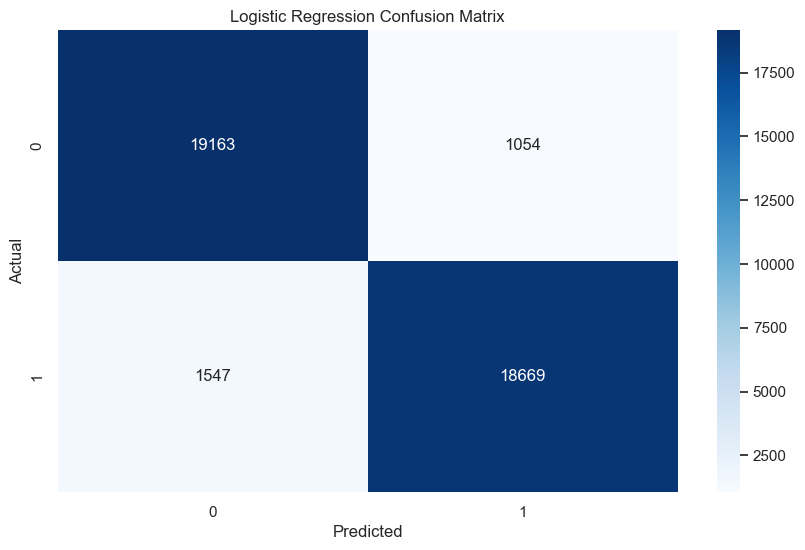

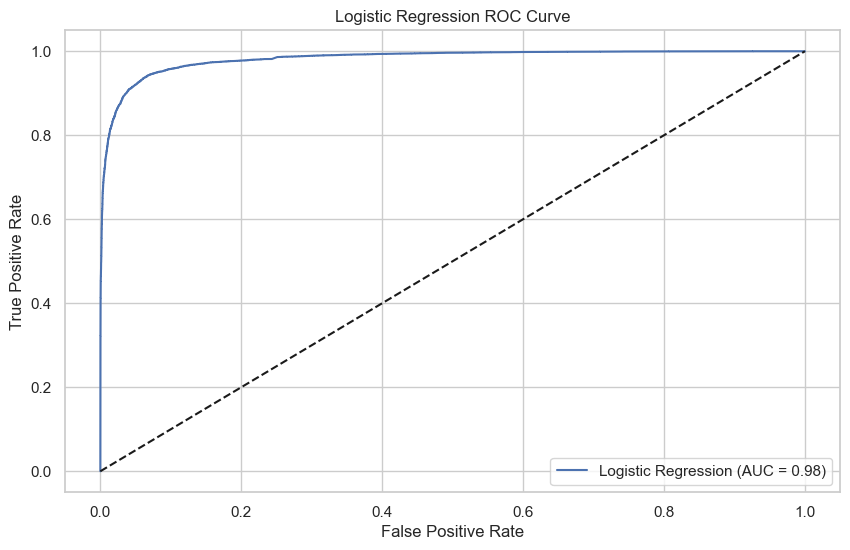


Random Forest Evaluation:
Accuracy: 0.8617218608562313
Precision: 0.9287096206835903
Recall: 0.7835872576177285
F1-Score: 0.8499986585464009
ROC-AUC: 0.9405086208092925

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.94      0.87     20217
           1       0.93      0.78      0.85     20216

    accuracy                           0.86     40433
   macro avg       0.87      0.86      0.86     40433
weighted avg       0.87      0.86      0.86     40433



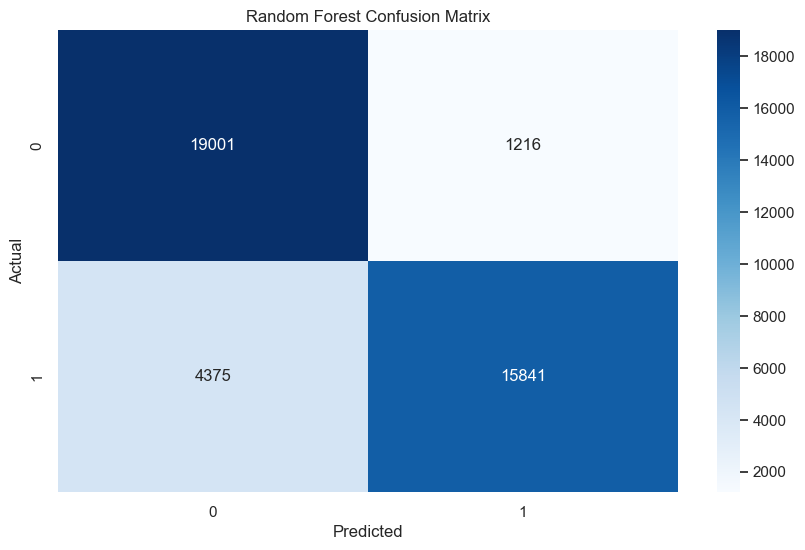

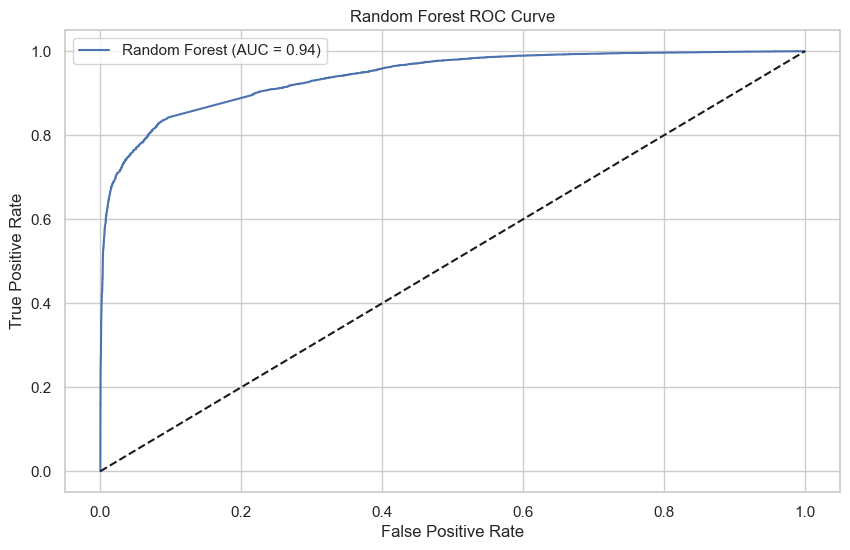

In [22]:
# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{model_name} Evaluation:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f'{model_name} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

# Evaluate both models
evaluate_model(model_lr, X_test, y_test, "Logistic Regression")
evaluate_model(model_rf, X_test, y_test, "Random Forest")

## Model Interpretation - Feature Importance


Top 15 Features for LR (Bullying Indicators):
fuck: 30.049
fucking: 23.620
idiot: 17.682
asshole: 16.267
suck: 14.434
stupid: 14.169
bitch: 14.042
fucker: 14.013
shit: 13.806
as: 13.451
page time: 13.164
bullshit: 12.710
article personal: 12.440
like article: 12.097
motherfucker: 12.009


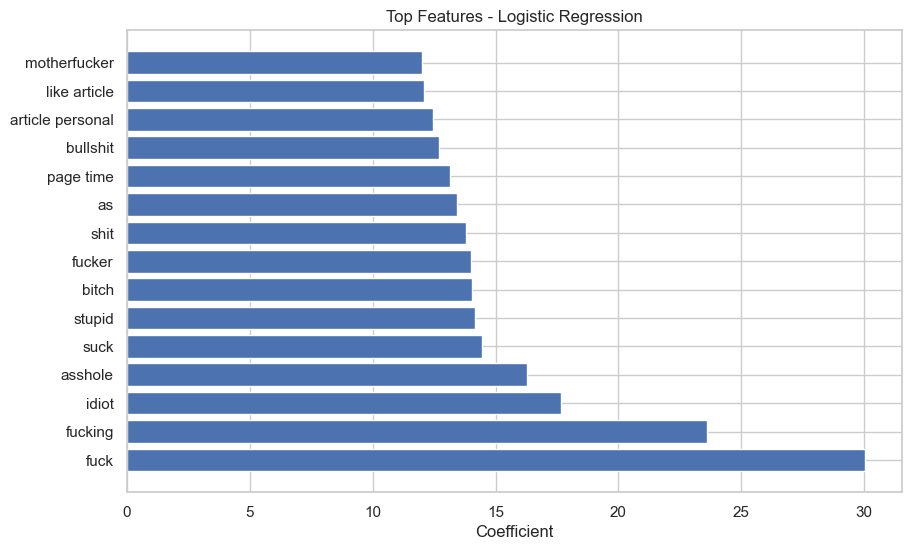


Top 15 Features for RF:
fuck: 0.068
fucking: 0.053
shit: 0.038
as: 0.030
article: 0.028
stupid: 0.023
idiot: 0.023
suck: 0.021
bitch: 0.019
asshole: 0.019
dick: 0.017
section: 0.013
faggot: 0.012
cock: 0.012
thanks: 0.012


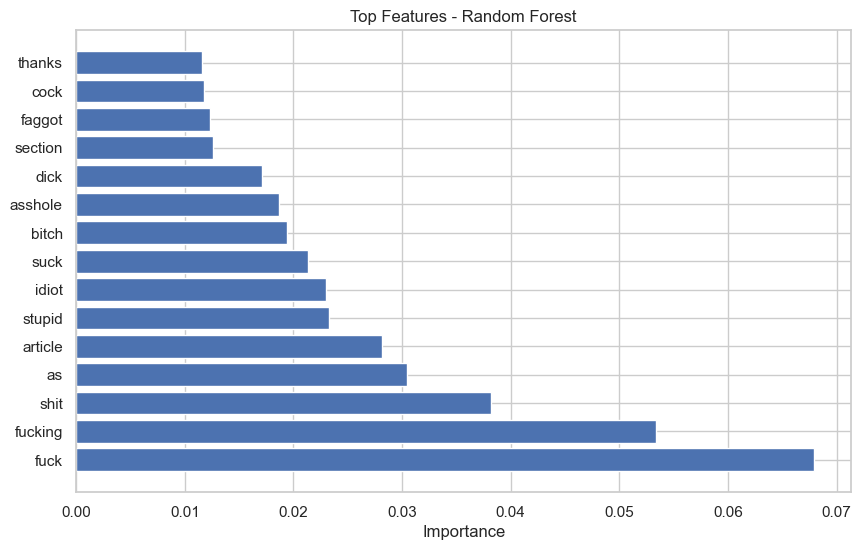

In [23]:
# For Logistic Regression
feature_names = vectorizer.get_feature_names_out()
coef_lr = model_lr.coef_[0]
top_features_lr = sorted(zip(coef_lr, feature_names), reverse=True)[:15]
print("\nTop 15 Features for LR (Bullying Indicators):")
for coef, feat in top_features_lr:
    print(f"{feat}: {coef:.3f}")

# Visualize
plt.barh([f[1] for f in top_features_lr], [f[0] for f in top_features_lr])
plt.title('Top Features - Logistic Regression')
plt.xlabel('Coefficient')
plt.show()

# For Random Forest
importances_rf = model_rf.feature_importances_
top_indices_rf = importances_rf.argsort()[-15:][::-1]
top_features_rf = [(importances_rf[i], feature_names[i]) for i in top_indices_rf]
print("\nTop 15 Features for RF:")
for imp, feat in top_features_rf:
    print(f"{feat}: {imp:.3f}")

# Visualize
plt.barh([f[1] for f in top_features_rf], [f[0] for f in top_features_rf])
plt.title('Top Features - Random Forest')
plt.xlabel('Importance')
plt.show()

## Error Analysis - Ambiguous/Misclassified Cases

In [24]:
# Get predictions and probabilities for LR
y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Find misclassified samples
misclassified_idx = np.where(y_pred_lr != y_test)[0]
print(f"\nNumber of Misclassified Samples (LR): {len(misclassified_idx)}")

# Sample 5 misclassified texts
print("\nSample Misclassified Texts (LR):")
for idx in misclassified_idx[:5]:
    original_idx = df_resampled.index[idx] if 'df_resampled' in globals() else idx
    text = df.loc[original_idx, 'Text'] if 'Text' in df.columns else "Text not available"
    actual = y_test.iloc[idx]
    pred = y_pred_lr[idx]
    prob = y_proba_lr[idx]
    print(f"Text: {text[:200]}...\nActual: {actual}, Predicted: {pred}, Prob: {prob:.2f}\n")

# Uncertainty: Samples with prob ~0.5
uncertainty = np.abs(y_proba_lr - 0.5)
uncertain_idx = np.argsort(uncertainty)[:10]
print("\nTop 10 Uncertain Predictions (LR):")
for idx in uncertain_idx:
    original_idx = df_resampled.index[idx] if 'df_resampled' in globals() else idx
    text = df.loc[original_idx, 'Text'] if 'Text' in df.columns else "Text not available"
    actual = y_test.iloc[idx]
    prob = y_proba_lr[idx]
    print(f"Text: {text[:200]}...\nActual: {actual}, Prob: {prob:.2f}\n")


Number of Misclassified Samples (LR): 2601

Sample Misclassified Texts (LR):
Text:   :If I may butt in  I've spent the last 1/4 hour following Andre, and I think he needs reining in. I left him a note at the deletion log, with a stern warning.  13:14 Aug 14, 2002 (PDT)...
Actual: 1, Predicted: 0, Prob: 0.47

Text:    On my  you will find the apology that I owe you.  [ shuffles his feet and looks at the floor]...
Actual: 0, Predicted: 1, Prob: 0.78

Text: gets far more tendentious yet. ...
Actual: 0, Predicted: 1, Prob: 0.53

Text: ```2000's: The Jewish blood-libel myth continues to circulate among many Muslim countries.`` - this is the only stuff relevant to present day, though there's lots of historical blood libel content whi...
Actual: 1, Predicted: 0, Prob: 0.07

Text: `  :Excuse me, what ``name`` did I call you? `...
Actual: 1, Predicted: 0, Prob: 0.27


Top 10 Uncertain Predictions (LR):
Text:   Yet another FUD-tastic contribution from . Did you copy the color template for that 

## Testing on Custom Examples

In [25]:
# Custom test sentences (expand with more)
test_sentences = [
    "You're so stupid, nobody likes you",
    "Great job on the presentation today!",
    "lol you're such a loser haha",
    "I disagree with your political opinion",
    "Women belong in the kitchen",
    "That's an interesting perspective, thanks for sharing",
    "Go kill yourself nobody wants you here",
    "Your cooking skills need improvement",
    # Add more from your earlier suggestions
    "You're worthless and everyone hates you",
    "Congrats on the promotion! Well deserved"
]

# Clean and vectorize
cleaned_tests = [clean_text(sent) for sent in test_sentences]
X_tests = vectorizer.transform(cleaned_tests)

# Predict with LR
preds_lr = model_lr.predict(X_tests)
probs_lr = model_lr.predict_proba(X_tests)[:, 1]

print("\nPredictions on Test Sentences (LR):")
for sent, pred, prob in zip(test_sentences, preds_lr, probs_lr):
    label = "Bullying" if pred == 1 else "Non-Bullying"
    print(f"Text: {sent}\nPrediction: {label} (Prob: {prob:.2f})\n")


Predictions on Test Sentences (LR):
Text: You're so stupid, nobody likes you
Prediction: Bullying (Prob: 1.00)

Text: Great job on the presentation today!
Prediction: Non-Bullying (Prob: 0.05)

Text: lol you're such a loser haha
Prediction: Bullying (Prob: 0.82)

Text: I disagree with your political opinion
Prediction: Non-Bullying (Prob: 0.19)

Text: Women belong in the kitchen
Prediction: Non-Bullying (Prob: 0.34)

Text: That's an interesting perspective, thanks for sharing
Prediction: Non-Bullying (Prob: 0.08)

Text: Go kill yourself nobody wants you here
Prediction: Bullying (Prob: 0.98)

Text: Your cooking skills need improvement
Prediction: Bullying (Prob: 0.87)

Text: You're worthless and everyone hates you
Prediction: Bullying (Prob: 0.98)

Text: Congrats on the promotion! Well deserved
Prediction: Non-Bullying (Prob: 0.07)



## Save Model and Vectorizer

In [26]:
import joblib

# Save best model (assuming LR is better; compare metrics)
joblib.dump(model_lr, 'cyberbullying_model_lr.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("\nModel and Vectorizer saved successfully.")


Model and Vectorizer saved successfully.


In [ ]:
import scipy.sparse as sp

# Save test split for use in Streamlit app
sp.save_npz('X_test_sparse.npz', X_test)
np.save('y_test.npy', y_test)

print("Test split saved successfully.")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

## Final Recommendations and Ethical Notes

In [27]:
print("\nKey Recommendations:")
print("1. Use the model as a flagging tool for human review, not automated actions.")
print("2. Monitor for biases (e.g., cultural/language-specific aggression).")
print("3. Regularly retrain with new data to handle evolving language/slurs.")
print("4. Ensure privacy: Anonymize texts before processing.")
print("5. Test on diverse datasets to improve generalization.")


Key Recommendations:
1. Use the model as a flagging tool for human review, not automated actions.
2. Monitor for biases (e.g., cultural/language-specific aggression).
3. Regularly retrain with new data to handle evolving language/slurs.
4. Ensure privacy: Anonymize texts before processing.
5. Test on diverse datasets to improve generalization.
